# Electrograms from local activation times

This tutorial approximates electrograms (EGMs) from a local activation time (LAT) map, one action-potential (AP) template, and a spatial sensitivity field for each electrode. The simulation supplies the LAT map and template; the EGM calculation then uses spatial gradients, weighted time bins, and a convolution without constructing a voltage movie for every tissue point.

The use of activation-shifted AP templates follows the modeling approach discussed by [Pezzuto et al. (2017)](https://doi.org/10.3389/fphys.2017.00265). The electrode sensitivity formulation is motivated by the lead-field treatment in [Potse (2018)](https://doi.org/10.3389/fphys.2018.00370). The derivation and binning scheme below explain this notebook's simplified implementation, rather than reproducing a complete bidomain or torso model from either paper.

## 1. Generate a LAT map and an AP template

The example uses a 256 × 256 grid with `dr = 0.2` mm, the Fenton–Karma model, and a central circular region with conductivity set to 0.3 instead of 1.0. A corner stimulus initiates propagation. `ActivationTimeTracker` records the first sampled crossing above 0.5, while `ActionPotentialTracker` records the AP at `[10, 10]`.

The integration step is 0.01 ms and both trackers run every 10 steps, giving a nominal sample interval of 0.1 ms. The AP derivative and the EGM time bins must use the AP sampling interval, not the integration step. This example assumes every included cell has activated and that the LAT map is finite and spatially meaningful.

In [ ]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import finitewave as fw

grid_size = 256
dr = 0.2

dist_map = np.zeros((grid_size, grid_size))
dist_map[grid_size // 2, grid_size // 2] = 1.0
dist_map = ndimage.distance_transform_edt(1 - dist_map)
mask = dist_map < 50

tissue = fw.CardiacTissue(shape=(grid_size, grid_size), dr=dr)
tissue.conductivity = np.ones((grid_size, grid_size))
tissue.conductivity[mask] = 0.3

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1.0,
                                           x_min=0, x_max=10,
                                           y_min=0, y_max=2))

act_pot_tracker = fw.ActionPotentialTracker([10, 10], step=10)
lat_tracker = fw.ActivationTimeTracker(threshold=0.5, step=10)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(lat_tracker)
tracker_sequence.add_tracker(act_pot_tracker)

simulation = fw.CardiacSimulation(dt=0.01, t_max=300, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.FentonKarma()
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

simulation.run()

lats = lat_tracker.output

plt.figure()
plt.imshow(lats, cmap="viridis", origin="lower",
           extent=[0, grid_size * dr, 0, grid_size * dr])
plt.colorbar(label="Activation time (ms)")
plt.contour(lats, origin="lower", levels=20, colors="white", linewidths=0.5, alpha=0.5,
            extent=[0, grid_size * dr, 0, grid_size * dr])
plt.title("Local Activation Time (LAT)")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()

## 2. Differentiate and align the AP template

Let $A(s)$ be the recorded AP, and let $a$ be its activation time on the template clock. For a tissue point with LAT $\tau(\mathbf{x})$, the shifted-template approximation is

$$
V_m(\mathbf{x},t) = A\bigl(t-\tau(\mathbf{x})+a\bigr).
$$

Define $g(u)=A'(u+a)$. Applying the chain rule gives

$$
\nabla V_m(\mathbf{x},t)=-g\bigl(t-\tau(\mathbf{x})\bigr)\nabla\tau(\mathbf{x}).
$$

These identities follow directly from the shared-template assumption. They separate the temporal waveform from the spatial activation pattern.

`compute_ap_derivative` returns `dvdt`, `act_time`, and `end_time`. In this implementation, `end_time = len(dvdt) * dt` is the duration represented by the retained samples, not their last absolute template time; `dvdt_times` is constructed separately for plotting. `np.gradient(v_ap, dt)` estimates $A'$. The default `act_time` is the sample with the largest positive derivative. In the current implementation, `upstroke_window=[0, 6]` selects **absolute template times** from 0 to 6 ms; it is not a window relative to activation. The cropped derivative is implicitly zero outside that interval during convolution. Use `None` to retain the recorded derivative, including any captured repolarization.

The LAT tracker uses a threshold crossing, whereas the default template alignment uses maximum slope. For consistent timing, supply `act_time` using the same activation criterion as the LAT map. Here the template begins at simulation time zero; a template recorded later would also need its time origin accounted for.

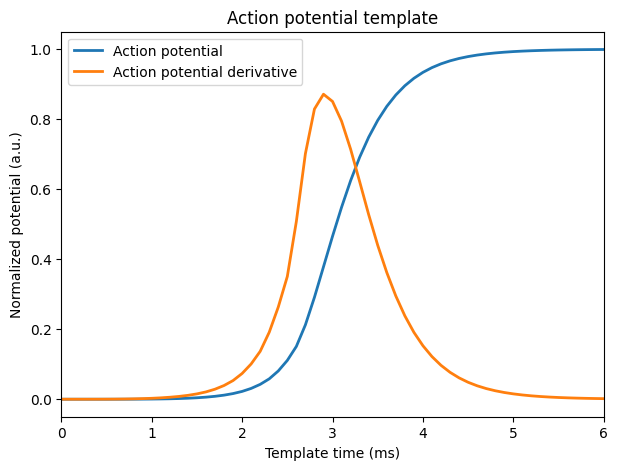

In [59]:
def compute_ap_derivative(v_ap, dt=0.1, act_time=None, upstroke_window=None):
    """Compute the time derivative of an action potential (AP) template.

    Parameters
    ----------
    v_ap : array_like
        Action potential template, sampled at uniform time intervals.
    dt : float, optional
        Time step between samples in v_ap (default: 0.1 ms).
    act_time : float, optional
        Activation time on the template clock (ms); defaults to maximum upstroke slope.
    upstroke_window : tuple of float, optional
        Absolute template-time window (start, end) in ms to restrict the derivative calculation
        to the upstroke phase of the AP (default: None, which uses the entire AP).

    Returns
    -------
    dvdt : ndarray
        Time derivative of the action potential, restricted to the upstroke window if specified.
    act_time : float
        Activation time on the template clock (ms).
    end_time : float
        End time of the upstroke window (ms), or the end of the AP if no window is specified.
    """
    v_ap = np.asarray(v_ap, dtype=float)
    dvdt = np.gradient(v_ap, dt)
    ap_times = np.arange(len(v_ap)) * dt

    if act_time is None:
        act_time = np.argmax(dvdt) * dt

    if upstroke_window is not None:
        start, end = upstroke_window

        if start < 0 or end > ap_times[-1]:
            raise ValueError("Upstroke window is out of bounds of the action potential template.")
        
        if start > act_time or end < act_time:
            raise ValueError("Upstroke window does not include the activation time.")

        keep = (ap_times >= start) & (ap_times <= end)

        if not np.any(keep):
            raise ValueError("Upstroke window does not overlap the template.")
        
        dvdt = dvdt[keep]

    end_time = len(dvdt) * dt
    
    return dvdt, act_time, end_time


times = act_pot_tracker.tracking_times
act_pot = act_pot_tracker.output
upstroke_window = [0, 6]  # ms
dvdt, act_time, end_time = compute_ap_derivative(act_pot, dt=0.1, upstroke_window=[0, 6])

dvdt_times = upstroke_window[0] + np.arange(len(dvdt)) * 0.1

plt.figure(figsize=(7, 5))
plt.plot(times, act_pot, lw=2, label="Action potential")
plt.plot(dvdt_times, dvdt, lw=2, label="Action potential derivative")
plt.title("Action potential template")
plt.ylabel("Normalized potential (a.u.)")
plt.xlabel("Template time (ms)")
plt.xlim(0, 6)
plt.legend()
plt.show()

## 3. Define the electrode sensitivity

`compute_lead_field` evaluates the inverse-distance field for each point electrode above the tissue sheet, including the extracellular conductivity prefactor:

$$
Z_m(x,y)=\frac{1}{4\pi\sigma_e\sqrt{(x-x_m)^2+(y-y_m)^2+h_m^2}}.
$$

The input `electrode_coords` contains `(row, col, height)` in grid units, either as one coordinate triple or an array of shape `(M, 3)`. The function converts all coordinate differences to millimeters using `dr` and returns `lead_fields` with shape `(M, Ny, Nx)`. A positive electrode height avoids a singularity on the sheet.

The example places two electrodes at 50% and 75% of the grid size along both spatial axes, each two grid spacings (0.4 mm) above the sheet. `sigma_extracellular = 0.3` is expressed in mS/mm, so the field values have units of inverse mS. The two panels show the fields for the two electrodes.

This homogeneous-conductor field is a simplified choice; a lead field incorporating a more detailed volume conductor can replace it ([Potse, 2018](https://doi.org/10.3389/fphys.2018.00370)). The extracellular conductivity factor is now included, but intracellular source conductivity, sheet thickness, and AP voltage calibration are still needed for physically calibrated EGM amplitudes.


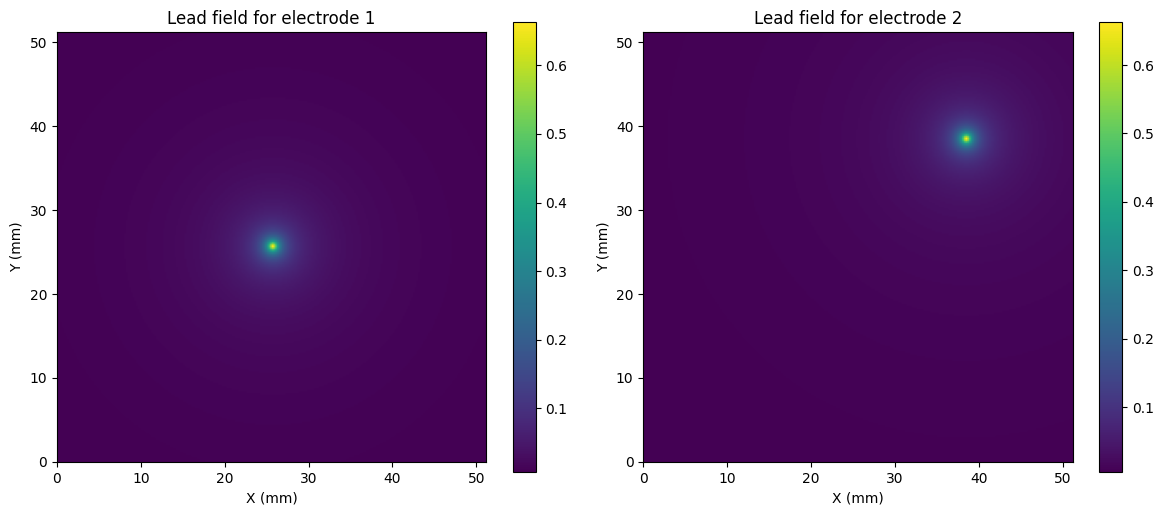

In [89]:
sigma_extracellular = 0.3  # mS/mm

def compute_lead_field(electrode_coords, shape, dr, sigma_extracellular=0.3):
    """Compute the lead field as an inverse distance function on a 2D grid.

    Parameters
    ----------
    electrode_coords : tuple of float
        Coordinates of the electrode in grid units (row, col, height).
    shape : tuple of int
        Shape of the 2D grid (rows, cols).
    dr : float
        Grid spacing in mm.
    sigma_extracellular : float, optional
        Extracellular conductivity in mS/mm (default: 0.3).

    Returns
    -------
    lead_field : ndarray
        Computed lead field values on the grid.
    """
    electrode_coords = np.array(electrode_coords)
    if electrode_coords.ndim == 1:
        electrode_coords = electrode_coords[np.newaxis, :]

    row, col = np.indices(shape)
    row_offset = (electrode_coords[:, 0, None, None] - row[None, ...]) * dr
    col_offset = (electrode_coords[:, 1, None, None] - col[None, ...]) * dr
    height_offset = electrode_coords[:, 2, None, None] * dr

    coeff = 1 / (4 * np.pi * sigma_extracellular)
    distance = np.sqrt(row_offset**2 + col_offset**2 + height_offset**2)
    lead_field = coeff / distance
    
    return lead_field


row, col = np.indices(lats.shape)
row_offset = row - grid_size // 2
col_offset = col - grid_size // 2
height_offset = 2

electrode_coords = [(0.50 * grid_size, 0.50 * grid_size, height_offset),
                    (0.75 * grid_size, 0.75 * grid_size, height_offset)]

lead_fields = compute_lead_field(electrode_coords, lats.shape, dr=dr,
                                 sigma_extracellular=sigma_extracellular)
lead_field = lead_fields[1]  # Use the lead field for the first electrode

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for i, ax in enumerate(axs):
    im = ax.imshow(lead_fields[i], cmap="viridis", origin="lower",
                   extent=[0, grid_size * dr, 0, grid_size * dr])
    ax.set_title(f"Lead field for electrode {i + 1}")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 4. Form the spatial source weights

Adopt the electrode polarity convention

$$
E_m(t)=-C\int_\Omega \nabla Z_m\cdot\boldsymbol{\sigma}_i\nabla V_m\,d\Omega,
$$

Here $Z_m$ already includes the extracellular conductivity prefactor, while $C$ can account for the sheet thickness or other remaining scale factors; do not apply the extracellular prefactor twice. Reversing the lead polarity reverses the sign. Substituting the shifted-template identity yields

$$
E_m(t)=C\int_\Omega
\left(\nabla Z_m\cdot\boldsymbol{\sigma}_i\nabla\tau\right)
 g(t-\tau)\,d\Omega.
$$

This is the tutorial's specialization of a gradient-based lead-field formulation ([Potse, 2018](https://doi.org/10.3389/fphys.2018.00370)). For the implemented scalar unit-intracellular-conductivity sheet approximation, define

$$
q_{m,p}=dr^2\sum_{k=0}^{1}(\partial_k Z_m)_p(\partial_k\tau)_p,
\qquad
E_m(t)\approx\sum_p q_{m,p}\,g(t-\tau_p).
$$

`compute_gradients` differentiates the two spatial axes and flattens the grid. With $P=N_yN_x$ tissue points and $M$ electrodes:

| Quantity | Shape | Meaning |
|---|---|---|
| `lat` | `(Ny, Nx)` | Activation times |
| `lead_fields` | `(M, Ny, Nx)` | Electrode sensitivity fields |
| `lat_grad` | `(2, 1, P)` | Two spatial LAT derivatives |
| `lead_field_grads` | `(2, M, P)` | Spatial lead-field derivatives for the contribution maps |
| `z_grad` | `(2, M, P)` | Lead-field derivatives multiplied by `dr**2` for EGM calculation |
| `np.sum(lat_grad * z_grad, axis=0)` | `(M, P)` | Spatial weights $q_{m,p}$ |

Broadcasting repeats the LAT gradient across electrodes; summing axis 0 takes the spatial dot product. `dr**2` is applied once in the final calculation to approximate the sheet-area integral. The two intermediate images below omit that area factor and show the spatial contribution map for each electrode.

The simulation's heterogeneous conductivity affects the LAT map, but is not explicitly multiplied into the EGM source weights in this implementation. Including a scalar conductivity map or a tensor requires the corresponding factor or tensor contraction in $q_{m,p}$.

(2, 2, 65536)


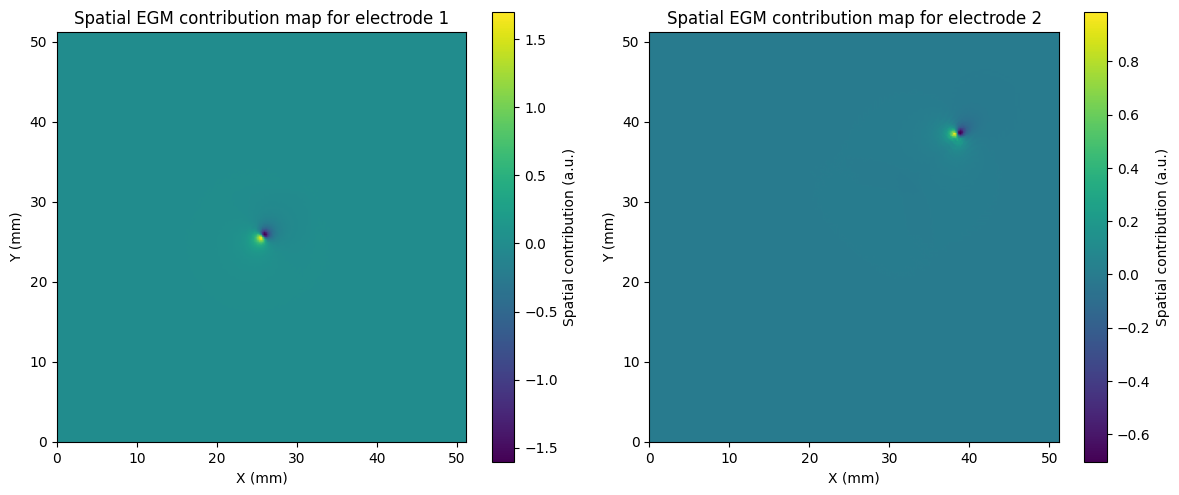

In [ ]:
def compute_gradients(x, dr):
    """Compute spatial gradients and flatten each electrode grid.

    Returns
    -------
    grad : ndarray
        Spatial derivatives shaped (2, M, Ny * Nx), ordered by row and column.
        A single (Ny, Nx) field is treated as M=1. No area factor is applied.
    """
    x = np.asarray(x, dtype=float)
    if x.ndim == 2:
        x = x[None, :, :]

    grad = np.gradient(x, dr, axis=(1, 2))
    # Flatten spatial dimensions to (2, M, Ny * Nx).
    grad = np.asarray(grad, dtype=float)
    grad = grad.reshape(*grad.shape[:2], -1)

    return grad


lead_field_grads = compute_gradients(lead_fields, dr=dr)
lat_grad = compute_gradients(lats, dr=dr)

source_weights = np.sum((lat_grad * lead_field_grads), axis=0)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for i, ax in enumerate(axs):
    source_weight_map = source_weights[i].reshape(lats.shape)
    im = ax.imshow(source_weight_map, cmap="viridis", origin="lower",
                   extent=[0, grid_size * dr, 0, grid_size * dr])
    ax.set_title(f"Spatial EGM contribution map for electrode {i + 1}")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    fig.colorbar(im, ax=ax, label="Spatial contribution (a.u.)")
plt.tight_layout()
plt.show()


## 5. Calculate electrograms

For each electrode, the spatial source weights are accumulated into activation-time bins, splitting each contribution between neighboring bins to preserve fractional LAT timing. The resulting weighted activation sequence is convolved with the AP derivative to obtain the EGM, and the returned signal is restricted to the interval between the earliest and latest LAT.


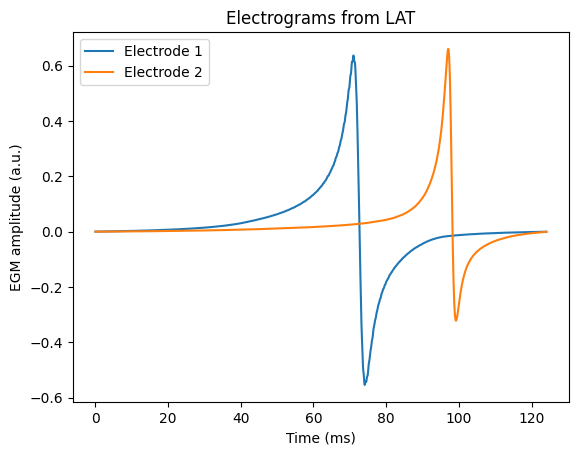

In [112]:
import numpy as np


def egm_from_lat(lat, z_grad, dvdt, act_time, end_time, dr, dt):
    """Calculate EGMs from LAT and explicit precomputed inputs.

    Parameters
    ----------
    lat : array_like
        Local activation time (LAT) map, sampled on a uniform grid.
    z_grad : array_like
        Electrode-field gradients multiplied by dr**2, shaped (2, M, Ny * Nx).
    dvdt : array_like
        Time derivative of the action potential, sampled at uniform time intervals.
    act_time : float
        Activation time on the AP template clock (ms).
    end_time : float
        End time of the upstroke window (ms).
    dr : float
        Spatial step between samples in lat (mm).
    dt : float
        Time step between samples in dvdt (ms).
    
    Returns
    -------
    time_ms : ndarray
        Time points corresponding to the EGM samples (ms).
    egm : ndarray
        Calculated electrograms, shaped (num_electrodes, num_time_points).

    """
    lat = np.asarray(lat, dtype=float)
    lat_grad = compute_gradients(lat, dr=dr)
    source_weights = np.sum(lat_grad * z_grad, axis=0)

    lat_min = lat.min()
    lat_max = lat.max()
    position = ((lat - lat_min) / dt).ravel()
    left = np.floor(position).astype(int)
    fraction = position - left
    n_bins = int(left.max()) + 2

    signals = []
    for electrode_weights in source_weights:
        w = electrode_weights.ravel()

        histogram = np.bincount(left, weights=w * (1 - fraction), minlength=n_bins)
        histogram += np.bincount(left + 1, weights=w * fraction, minlength=n_bins)

        signals.append(np.convolve(histogram, dvdt, mode="full"))

    egm = np.stack(signals)
    right_overlap_time = end_time - act_time
    times = lat_min - right_overlap_time + np.arange(egm.shape[1]) * dt
    mask = (times >= lat_min) & (times <= lat_max)
    time_ms = times[mask]
    egm = egm[:, mask]
    return time_ms, egm


z_grad = compute_gradients(lead_fields, dr)
z_grad *= dr**2

lat_grad = compute_gradients(lats, dr)
dvdt, act_time, end_time = compute_ap_derivative(act_pot, dt=0.1, upstroke_window=[0, 6])


time_ms, egms = egm_from_lat(lats, z_grad, dvdt, act_time, end_time, dr=dr, dt=0.1)

plt.figure()
for electrode_index, egm in enumerate(egms):
    plt.plot(time_ms, egm, label=f"Electrode {electrode_index + 1}")
plt.title("Electrograms from LAT")
plt.xlabel("Time (ms)")
plt.ylabel("EGM amplitude (a.u.)")
plt.legend()
plt.show()

## Reusing the calculation and interpreting the result

- Precompute `z_grad` for fixed lead fields and grid spacing, including `dr**2` exactly once. Recompute it when electrode geometry, extracellular conductivity, or spacing changes.
- Precompute `dvdt`, `act_time`, and `end_time` for a fixed AP and window. Recompute them when the template or sampling changes.
- For each new LAT map, recompute its gradient, spatial weights, and bin indices/fractions. The bin indices and fractions are shared across electrodes.
- For $P$ cells, $M$ electrodes, $B$ time bins, and $L$ AP samples, binning costs approximately $O(M(P+B))$ and direct convolution $O(MBL)$. This avoids a $(P,T)$ voltage movie. Profile before optimizing; long convolutions may benefit from an FFT implementation.

This approximation assumes a single activation per cell and one AP shape shared throughout the tissue. Spatial variation in AP amplitude or duration, repeated activation, and local waveform changes are not represented by a single LAT map and template. LAT gradients also amplify map noise and discontinuities. Nonactivated cells (including tracker sentinel values), holes, or invalid LATs need an explicit tissue mask and a suitable spatial derivative treatment; they must not be treated as ordinary activation times.

The sample retains only an early AP interval, so its EGM emphasizes depolarization. A longer template alone does not reproduce spatially varying repolarization. Distances are now converted to millimeters and the extracellular conductivity prefactor is included. Absolute amplitudes still require voltage calibration, intracellular source conductivity, and a sheet thickness or 3D volume integration. The notes above identify the current timing and scaling assumptions.

**Timing in the current implementation:** `egm_from_lat` sets the first convolution time to `lat_min - (end_time - act_time)`, with `end_time` computed as the retained sample count times `dt`. A template aligned by its activation time instead requires the first retained template time minus `act_time` as the offset from `lat_min`; these offsets generally differ. The window start is not passed to the current EGM function, so arbitrary nonzero window starts are not fully represented, and the final LAT-range crop can remove signal tails.

## References

1. Pezzuto S., Kal'avský P., Potse M., Prinzen F. W., Auricchio A., and Krause R. (2017). [Evaluation of a Rapid Anisotropic Model for ECG Simulation](https://doi.org/10.3389/fphys.2017.00265). *Frontiers in Physiology*, **8**, 265. Background on activation times, shifted AP templates, and lead-field ECG calculation.
2. Potse M. (2018). [Scalable and Accurate ECG Simulation for Reaction-Diffusion Models of the Human Heart](https://doi.org/10.3389/fphys.2018.00370). *Frontiers in Physiology*, **9**, 370. Lead-field formulation and precomputation of electrode-dependent quantities.